In [1]:
import numpy as np
import skexplain
import seaborn as sns
import plotting_config
import matplotlib as mpl
import itertools
import scipy
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor

In [2]:
def get_twinx(ax):
    for ax2 in ax.figure.axes:
        if ax2 is not ax and ax.get_shared_x_axes().joined(ax, ax2):
            return ax2
    return None

load data

In [3]:
ale_dataset_19 = xr.open_dataset('figures/figure_data/fig_2d_ale19.nc')
ale_dataset_23 = xr.open_dataset('figures/figure_data/fig_2d_ale23.nc')

ice_dataset_19 = xr.open_dataset('figures/figure_data/fig_2d_ice19_11w_new.nc')
ice_dataset_23 = xr.open_dataset('figures/figure_data/fig_2d_ice23_11w_new.nc')

In [39]:
ice_dataset_23

<xarray.Dataset>
Dimensions:                     (n_bootstrap: 110000, n_bins__conformity: 20,
                                 feature: 1)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, feature
Data variables:
    conformity__RNN_Model__ice  (n_bootstrap, n_bins__conformity) float64 -0....
    conformity__bin_values      (n_bins__conformity) float32 1.607 ... 10.62
    X_sampled                   (n_bootstrap, feature) float64 -0.03623 ... -...
    features                    (feature) object 'first_values'
Attributes:
    estimator_output:  raw
    estimators used:   RNN_Model
    method:            ale
    dimension:         1D
    features used:     conformity

set colorbar object

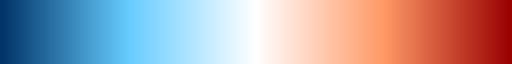

In [4]:
colors = ["#003366", "#66CCFF", "#FFFFFF", "#FF9966", "#990000"]

# Create a continuous colormap object from a list of colors.
my_cmap = mcolors.LinearSegmentedColormap.from_list("111", colors)
my_cmap

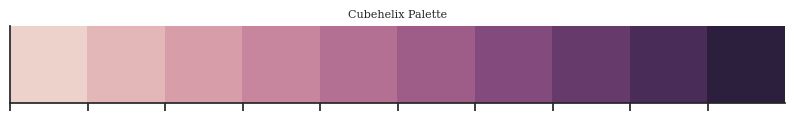

In [5]:
cubehelix_palette = sns.cubehelix_palette(n_colors=10)
sns.palplot(cubehelix_palette)
plt.title('Cubehelix Palette')
plt.show()

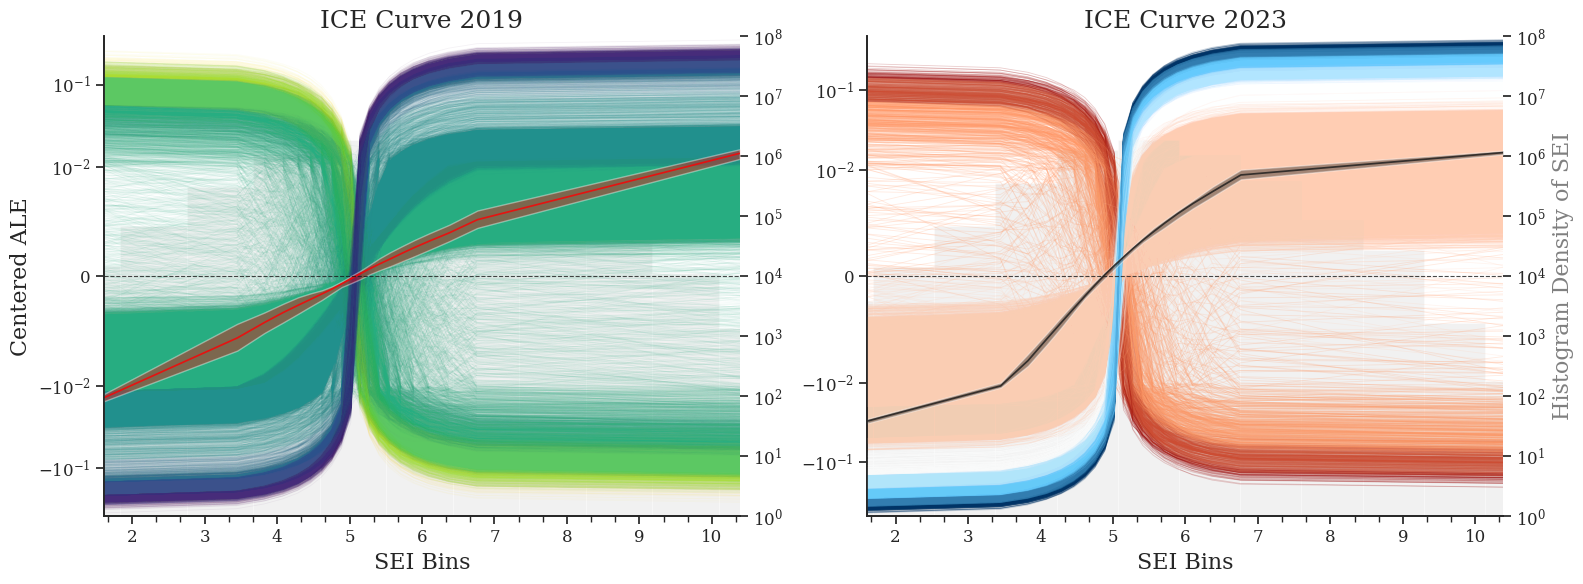

In [6]:
# Create a 1×2 figure layout
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns, figure size 16×6
estimator = [('RNN_Model', RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# Plot ALE and ICE curves for RNN_Model_19
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',  # x-axis label
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    hist_color='lightgrey',      # histogram color
    ice_color='#2E167E',         # ICE curve color
    color_by='first_values',     # color ICE curves by these values
    yscale='symlog',
    y_linscale=1.2,              # smaller values enlarge the region near zero
    show_colorbar=False,
    ice_alpha=0.05,
    ice_linewidth=0.6,
    wspace=0.15,
    ax=axs[0]                    # draw on the first subplot
)
axs[0].set_xlabel('SEI Bins', fontsize=16)
axs[0].set_ylabel('Centered ALE', fontsize=16)
axs[0].set_title('ICE Curve 2019', fontsize=18)
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)

ax0_right = get_twinx(axs[0])
if ax0_right:
    ax0_right.tick_params(axis='y', labelsize=12)

# Plot ALE and ICE curves for RNN_Model_23
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    line_kws={"line_colors": 'k'},  # ALE curve color
    hist_color='lightgrey',
    ice_cmap=my_cmap,               # colormap for ICE curves
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.2,                 # smaller values enlarge the region near zero
    show_colorbar=False,
    ice_split_threshold=[-0.05, -0.02],  # interval thresholds
    ice_alpha=[0.05, 0.2],                # transparency inside / outside intervals
    ice_linewidth=[0.1, 0.6],
    wspace=0.15,
    ax=axs[1]                            # draw on the second subplot
)

axs[1].set_xlabel('SEI Bins', fontsize=16)
axs[1].set_title('ICE Curve 2023', fontsize=18)
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)

ax1_right = get_twinx(axs[1])
if ax1_right:
    ax1_right.tick_params(axis='y', labelsize=12)
    ax1_right.set_ylabel('Histogram Density of SEI', fontsize=16, color='gray')

# Adjust layout
plt.tight_layout()

# Display the figure
plt.show()

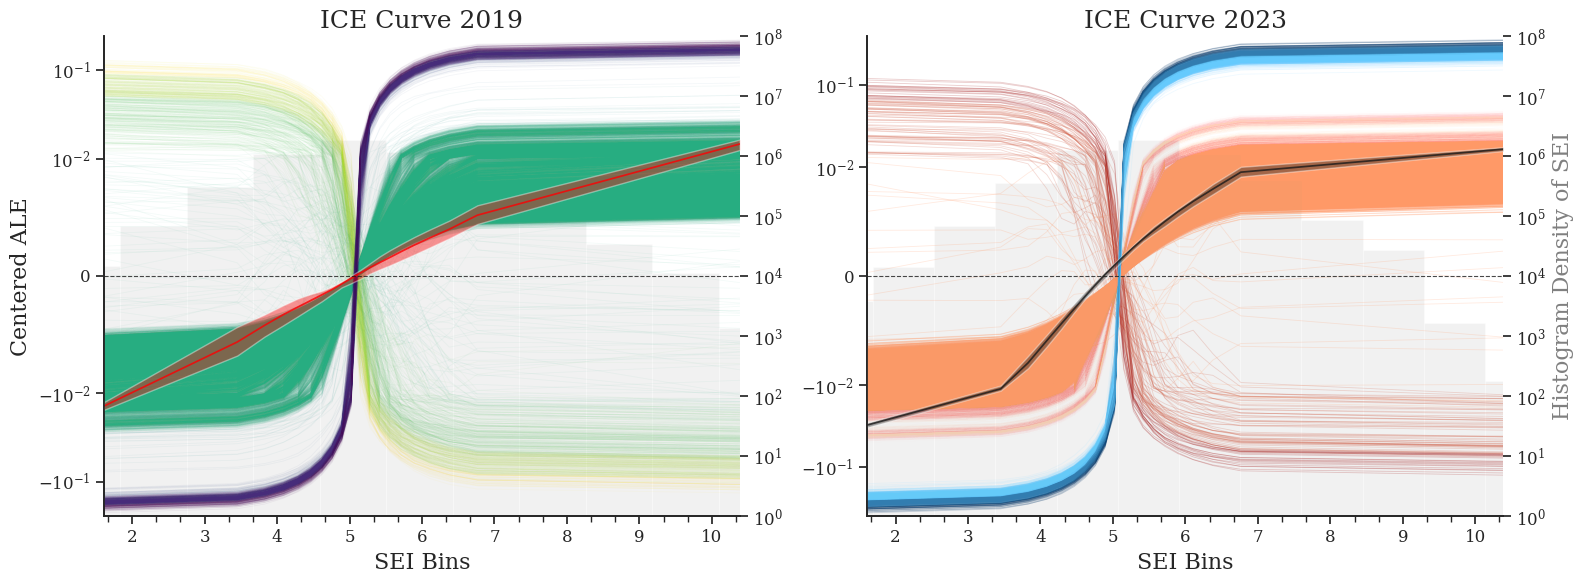

In [7]:
# 创建1×2的图窗
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1行2列的图窗，尺寸为12×6
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# 绘制 RNN_Model_19 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',  # x轴名字
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    hist_color = 'lightgrey',  # 直方图颜色
    ice_color = '#2E167E',  # ice曲线颜色
    color_by='first_values', # 按哪里的数值着色
    yscale='symlog',
    y_linscale=1.2, # 越小零附近放大越强
    show_colorbar=False, 
    ice_alpha=0.05,
    ice_linewidth=0.6,
    wspace=0.15,
    ax=axs[0]  # 绘制在第一个子图中
)
axs[0].set_xlabel('SEI Bins', fontsize=16)
axs[0].set_ylabel('Centered ALE', fontsize=16)
axs[0].set_title('ICE Curve 2019', fontsize=18)  # 设置标题
axs[0].tick_params(axis='x', labelsize=12)          # x 轴刻度字体
axs[0].tick_params(axis='y', labelsize=12) 
ax0_right = get_twinx(axs[0])
if ax0_right:
    ax0_right.tick_params(axis='y', labelsize=12)

# 绘制 RNN_Model_23 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    line_kws = {"line_colors":'k'},  # ale曲线颜色
    hist_color = 'lightgrey',
    # ice_cmap='cool',
    ice_cmap = my_cmap,  # colorbar颜色
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.2, # 越小零附近放大越强
    show_colorbar=False, 
    ice_split_threshold = [-0.05,-0.02],  # 区间设置
    ice_alpha=[0.05,0.2],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.1,0.6],
    wspace=0.15,
    ax=axs[1]  # 绘制在第二个子图中
)

axs[1].set_xlabel('SEI Bins', fontsize=16)
axs[1].set_title('ICE Curve 2023', fontsize=18)  # 设置标题
axs[1].tick_params(axis='x', labelsize=12)          # x 轴刻度字体
axs[1].tick_params(axis='y', labelsize=12) 
ax1_right = get_twinx(axs[1])
if ax1_right:
    ax1_right.tick_params(axis='y', labelsize=12)
    ax1_right.set_ylabel('Histogram Density of SEI', fontsize=16, color='gray')

# 调整图窗布局
plt.tight_layout()

# 显示图窗
plt.show()

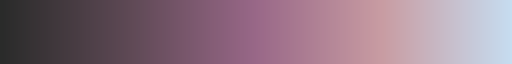

In [5]:
colors = ["#2A2B2A", "#5E4955", "#996888", "#C99DA3", "#C6DDF0"]

my_cmap = mcolors.LinearSegmentedColormap.from_list("111", colors)
my_cmap

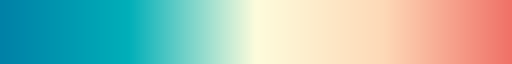

In [6]:
# colors_2 = ["#0081a7", "#00afb9", "#fdfcdc", "#fed9b7", "#f07167"]
colors_2 = ["#0081a7", "#00afb9", "#fdfcdc","#fed9b7", "#f07167"]

my_cmap_2 = mcolors.LinearSegmentedColormap.from_list("111", colors_2)
my_cmap_2

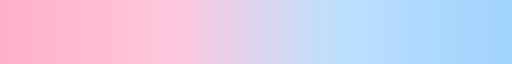

In [7]:
colors_4 = [ "#ffafcc","#ffc8dd", "#bde0fe","#a2d2ff"]

my_cmap_4 = mcolors.LinearSegmentedColormap.from_list("111", colors_4)
my_cmap_4

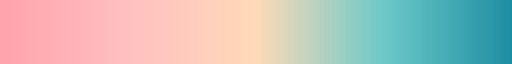

In [11]:
# colors_6 = ["#ffa3ac", "#ffc0c2", "#ffdab9","#bee9e8","#62b6cb","#6dc9c8", "#1f8ea3"]
colors_6 = ["#ffa3ac", "#ffc0c2", "#ffdab9", "#028090"]

colors_6 = ["#ffa3ac", "#ffc0c2", "#ffdab9","#6dc9c8", "#1f8ea3"]

my_cmap_6 = mcolors.LinearSegmentedColormap.from_list("111", colors_6)
my_cmap_6

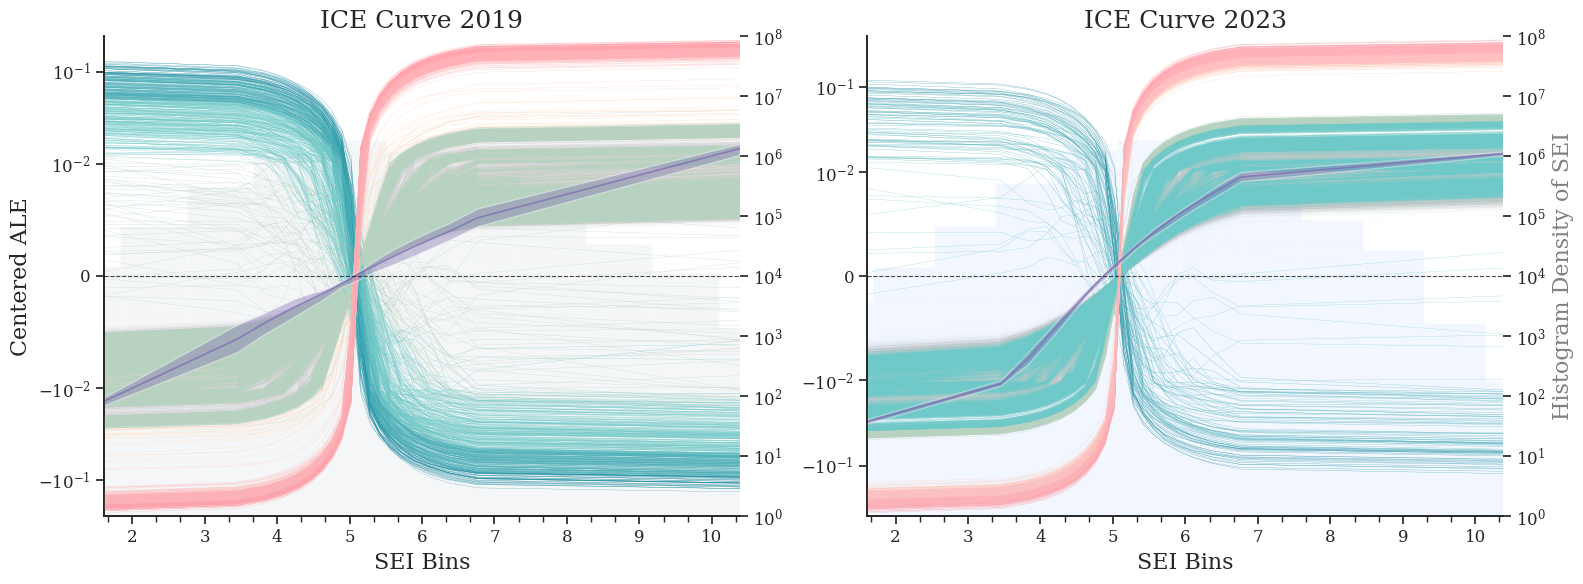

In [15]:
# new_test
# 创建1×2的图窗
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1行2列的图窗，尺寸为12×6
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# 绘制 RNN_Model_19 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',  # x轴名字
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    line_kws =  {"line_colors": 'm'} ,  # ale曲线颜色
    hist_color = '#dee2e6',  # 直方图颜色
    # ice_color = '#2E167E',  # ice曲线颜色
    ice_cmap = my_cmap_6,  # colorbar颜色
    color_by='first_values', # 按哪里的数值着色
    yscale='symlog',
    y_linscale=1.1, # 越小零附近放大越强
    show_colorbar=False, 
    # ice_alpha=0.05,
    # ice_linewidth=0.6,
    ice_split_threshold = [-0.02,-0.002],  # 区间设置
    ice_alpha=[0.9,0.8],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.0035,0.2],
    wspace=0.15,
    ax=axs[0]  # 绘制在第一个子图中
)
axs[0].set_xlabel('SEI Bins', fontsize=16)
axs[0].set_ylabel('Centered ALE', fontsize=16)
axs[0].set_title('ICE Curve 2019', fontsize=18)  # 设置标题
axs[0].tick_params(axis='x', labelsize=12)          # x 轴刻度字体
axs[0].tick_params(axis='y', labelsize=12) 
ax0_right = get_twinx(axs[0])
if ax0_right:
    ax0_right.tick_params(axis='y', labelsize=12)

# 绘制 RNN_Model_23 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    line_kws = {"line_colors":'m'},  # ale曲线颜色
    hist_color = '#d7e3fc',
    # ice_cmap='cool',
    ice_cmap = my_cmap_6,  # colorbar颜色
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.1, # 越小零附近放大越强
    show_colorbar=False, 
    ice_split_threshold = [-0.02,-0.002],  # 区间设置
    ice_alpha=[0.9,0.8],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.0035,0.2],
    wspace=0.15,
    ax=axs[1]  # 绘制在第二个子图中
)

axs[1].set_xlabel('SEI Bins', fontsize=16)
axs[1].set_title('ICE Curve 2023', fontsize=18)  # 设置标题
axs[1].tick_params(axis='x', labelsize=12)          # x 轴刻度字体1
axs[1].tick_params(axis='y', labelsize=12) 
ax1_right = get_twinx(axs[1])
if ax1_right:
    ax1_right.tick_params(axis='y', labelsize=12)
    ax1_right.set_ylabel('Histogram Density of SEI', fontsize=16, color='gray')

# 调整图窗布局
plt.tight_layout()

# 显示图窗
plt.show()

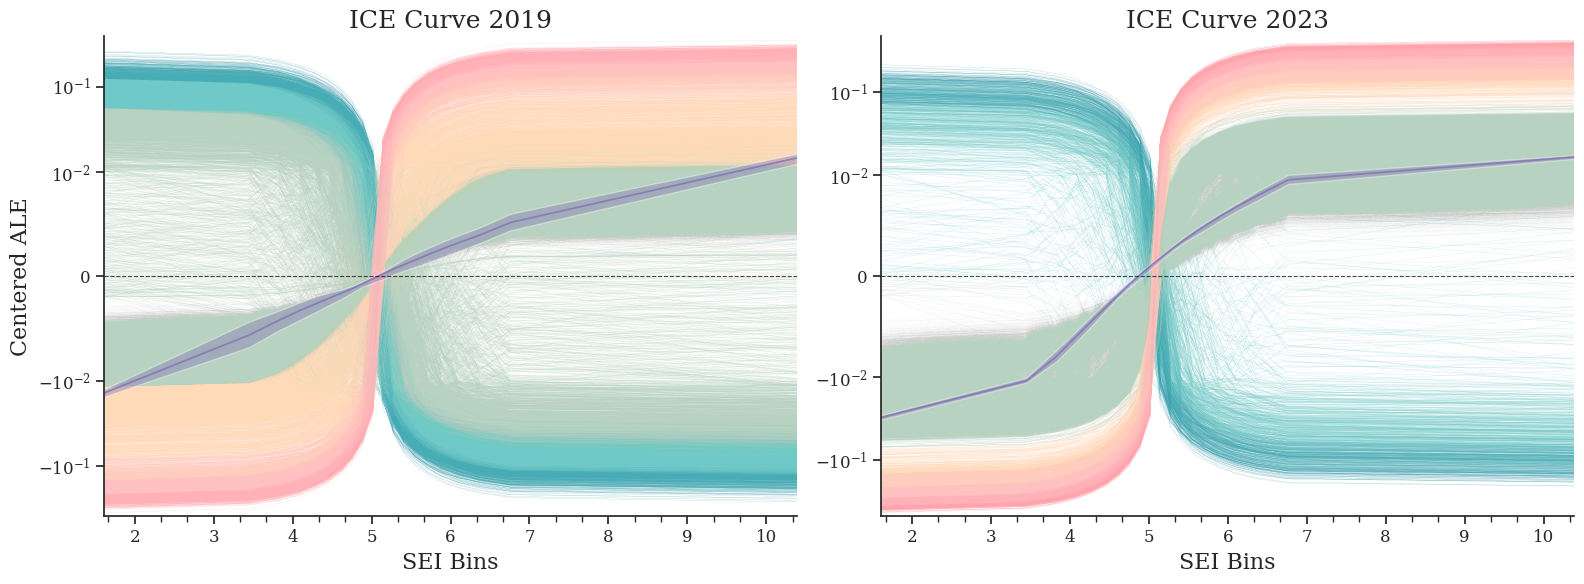

In [12]:
# new_test
# 创建1×2的图窗
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1行2列的图窗，尺寸为12×6
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# 绘制 RNN_Model_19 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',  # x轴名字
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    line_kws =  {"line_colors": 'm'} ,  # ale曲线颜色
    hist_color = 'w',  # 直方图颜色
    # ice_color = '#2E167E',  # ice曲线颜色
    ice_cmap = my_cmap_6,  # colorbar颜色
    color_by='first_values', # 按哪里的数值着色
    yscale='symlog',
    y_linscale=1.1, # 越小零附近放大越强
    show_colorbar=False, 
    # ice_alpha=0.05,
    # ice_linewidth=0.6,
    ice_split_threshold = [-0.02,-0.002],  # 区间设置
    ice_alpha=[0.9,0.8],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.0005,0.1],
    wspace=0.15,
    ax=axs[0]  # 绘制在第一个子图中
)
axs[0].set_xlabel('SEI Bins', fontsize=16)
axs[0].set_ylabel('Centered ALE', fontsize=16)
axs[0].set_title('ICE Curve 2019', fontsize=18)  # 设置标题
axs[0].tick_params(axis='x', labelsize=12)          # x 轴刻度字体
axs[0].tick_params(axis='y', labelsize=12) 
ax0_right = get_twinx(axs[0])
if ax0_right:
    ax0_right.set_visible(False) 
    # ax0_right.tick_params(axis='y', labelsize=12)

# 绘制 RNN_Model_23 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    line_kws = {"line_colors":'m'},  # ale曲线颜色
    hist_color = 'w',
    # ice_cmap='cool',
    ice_cmap = my_cmap_6,  # colorbar颜色
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.1, # 越小零附近放大越强
    show_colorbar=False, 
    ice_split_threshold = [-0.02,-0.002],  # 区间设置
    ice_alpha=[0.9,0.8],  #[区间内透明度，区间外透明度]
    ice_linewidth=[0.0002,0.1],
    wspace=0.15,
    ax=axs[1]  # 绘制在第二个子图中
)

axs[1].set_xlabel('SEI Bins', fontsize=16)
axs[1].set_title('ICE Curve 2023', fontsize=18)  # 设置标题
axs[1].tick_params(axis='x', labelsize=12)          # x 轴刻度字体1
axs[1].tick_params(axis='y', labelsize=12) 
ax1_right = get_twinx(axs[1])
if ax1_right:
    ax1_right.set_visible(False) 
    # ax1_right.tick_params(axis='y', labelsize=12)
    # ax1_right.set_ylabel('Histogram Density of SEI', fontsize=16, color='gray')

# 调整图窗布局
plt.tight_layout()

# 显示图窗
plt.show()

## Change logit of coloring

In [67]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [31]:
# adopt K-means to classify ice curves
ice19 = ice_dataset_19["conformity__RNN_Model__ice"].values  # shape (110000, 20)
ice23 = ice_dataset_23["conformity__RNN_Model__ice"].values
bins19 = ice_dataset_19["conformity__bin_values"].values
bins23 = ice_dataset_23["conformity__bin_values"].values 

In [49]:
# what about clustering via slope?
def compute_global_slope(ice, x):
    x = np.asarray(x)
    # 为了数值稳定，可以对 x 做标准化（不改 y，只改坐标系）
    x_scaled = (x - x.mean()) / x.std()
    
    # 设计矩阵： [x_scaled, 1]
    X = np.vstack([x_scaled, np.ones_like(x_scaled)]).T      # shape (n_bins, 2)

    # 最小二乘闭式解：beta = (X^T X)^(-1) X^T Y
    # Y 是所有曲线堆成的矩阵: shape (n_bins, n_samples)
    Y = ice.T                                                # (n_bins, n_samples)
    
    XtX_inv = np.linalg.inv(X.T @ X)                         # (2, 2)
    beta = XtX_inv @ X.T @ Y                                 # (2, n_samples)
    
    slopes = beta[0, :]                                      # 第一行是斜率
    return slopes

In [63]:
slopes19 = compute_global_slope(ice19, bins19)
slopes23 = compute_global_slope(ice23, bins23)

In [64]:
# --------- 首先划分出 反从众（斜率 < 0） ----------
anti_mask_19 = slopes19 < 0
anti_mask_23 = slopes23 < 0

# 给 2019 的初始标签
labels19 = np.full(len(slopes19), -1)
labels19[anti_mask_19] = 0   # 0 → 反从众

# 给 2023 初始标签
labels23 = np.full(len(slopes23), -1)
labels23[anti_mask_23] = 0   # 0 → 反从众

In [65]:
# 2019 的正斜率部分（候选从众）

# --------- 在正斜率样本中做 2 类 GMM ----------
# --------- 1. 对 2019 正斜率做模型训练并映射 ---------
slopes19_pos = slopes19[~anti_mask_19].reshape(-1, 1)

# gmm_pos = GaussianMixture(n_components=2, random_state=0)
# gmm_pos.fit(slopes19_pos)
# labels_pos_19 = gmm_pos.predict(slopes19_pos)

kmeans = KMeans(n_clusters=2, random_state=0).fit(slopes19_pos)
labels_pos_19 = kmeans.labels_

# 计算 2019 两个 cluster 的平均斜率
means19 = [
    (0, slopes19_pos[labels_pos_19 == 0].mean()),
    (1, slopes19_pos[labels_pos_19 == 1].mean())
]
means19_sorted = sorted(means19, key=lambda x: x[1])

# 2019 映射（小斜率=一般从众=1，大斜率=强从众=2）
mapping19 = {
    means19_sorted[0][0]: 1,
    means19_sorted[1][0]: 2
}

# 应用到 2019
labels19[~anti_mask_19] = [mapping19[l] for l in labels_pos_19]


# --------- 2. 对 2023 做预测，并独立确定含义 ---------
slopes23_pos = slopes23[~anti_mask_23].reshape(-1, 1)

# labels_pos_23 = gmm_pos.predict(slopes23_pos)
labels_pos_23 = kmeans.predict(slopes23_pos)

# 计算 2023 两类的平均斜率
means23 = [
    (0, slopes23_pos[labels_pos_23 == 0].mean()),
    (1, slopes23_pos[labels_pos_23 == 1].mean())
]
means23_sorted = sorted(means23, key=lambda x: x[1])

# 2023 映射（按 2023 的均值自己排序！）
mapping23 = {
    means23_sorted[0][0]: 1,
    means23_sorted[1][0]: 2
}

labels23[~anti_mask_23] = [mapping23[l] for l in labels_pos_23]

In [68]:
# 计算比例值
def print_cluster_ratio(labels, year):
    total = len(labels)
    print(f"\n===== {year} 年类别比例 =====")
    for k, name in {0:"反从众", 1:"一般从众", 2:"强从众"}.items():
        count = np.sum(labels == k)
        ratio = count / total * 100
        print(f"{name}({k}): {count} 个，占 {ratio:.2f}%")

# 输出
print_cluster_ratio(labels19, 2019)
print_cluster_ratio(labels23, 2023)


===== 2019 年类别比例 =====
反从众(0): 4125 个，占 3.75%
一般从众(1): 100278 个，占 91.16%
强从众(2): 5597 个，占 5.09%

===== 2023 年类别比例 =====
反从众(0): 771 个，占 0.70%
一般从众(1): 99254 个，占 90.23%
强从众(2): 9975 个，占 9.07%


In [79]:
# 不渐变做法
cluster_colors = {
    0: "#1f8ea3",
    1: "#ffdab9",
    2: "#ffa3ac" 
}


In [73]:
def get_curve_colors(initial_values, labels, my_cmap, cluster_cmap_ranges):
    """
    根据 initial values 和簇标签生成颜色列表
    """
    n = len(labels)
    colors = [None] * n

    unique_clusters = sorted(cluster_cmap_ranges.keys())

    for cls in unique_clusters:
        idx = np.where(labels == cls)[0]
        vals = initial_values[idx]

        # 类内归一化
        vmin, vmax = vals.min(), vals.max()
        norm_vals = (vals - vmin) / (vmax - vmin + 1e-8)

        # 该类的 colormap 区段
        left, right = cluster_cmap_ranges[cls]

        for i, nv in zip(idx, norm_vals):
            # 把 norm_val 映射到整体 colormap 的子区间
            global_pos = left + nv * (right - left)
            colors[i] = my_cmap(global_pos)

    return colors

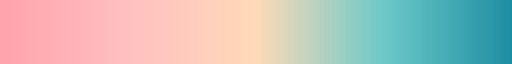

In [74]:
colors_6 = ["#ffa3ac", "#ffc0c2", "#ffdab9","#6dc9c8", "#1f8ea3"]
# 从颜色列表生成一个连续 colormap 对象
my_cmap_6 = mcolors.LinearSegmentedColormap.from_list("111", colors_6)
my_cmap_6

In [76]:
cluster_cmap_ranges = {
    0: (0.0, 0.30),   # 反从众：整体 colormap 的前 30%
    1: (0.30, 0.60),  # 一般从众：中间 30%
    2: (0.60, 1.00),  # 强从众：最后 40%
}

In [77]:
initial_values_19 = ice_dataset_19["X_sampled"].values[:, 0]
initial_values_23 = ice_dataset_23["X_sampled"].values[:, 0]

colors19 = get_curve_colors(initial_values_19, labels19, my_cmap_6, cluster_cmap_ranges)
colors23 = get_curve_colors(initial_values_23, labels23, my_cmap_6, cluster_cmap_ranges)

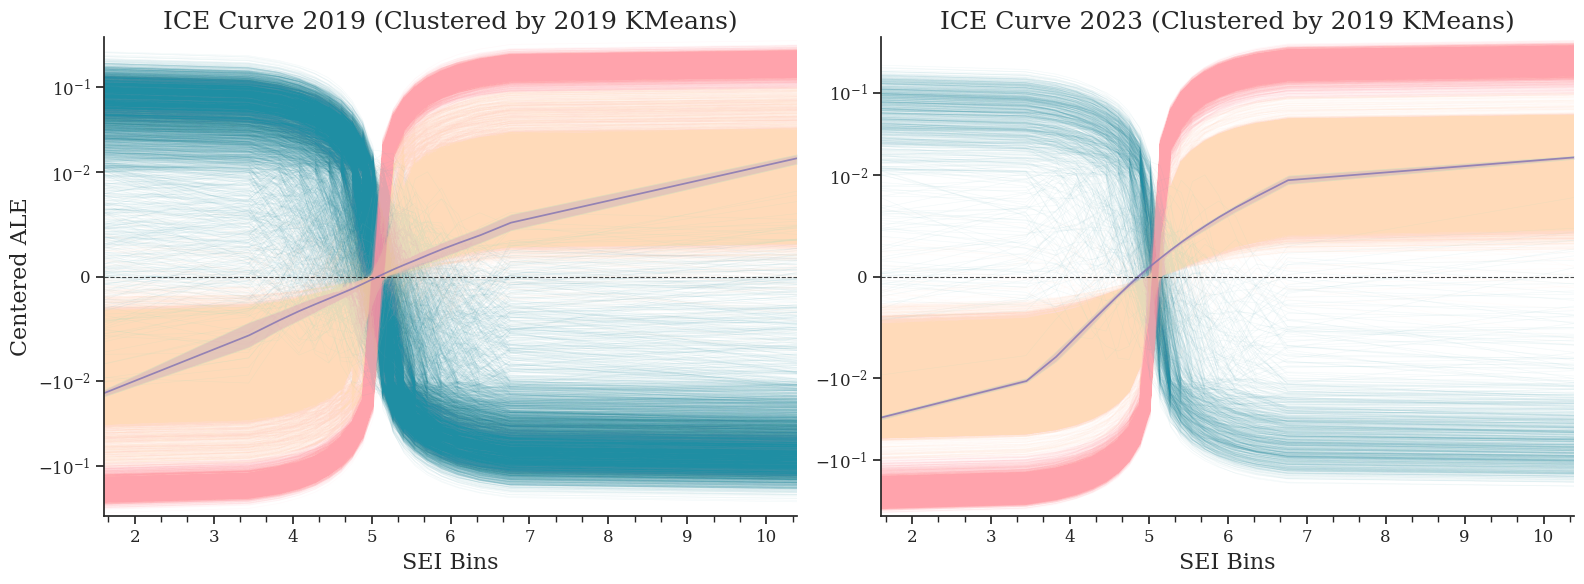

In [80]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# ---------- 2019 ----------
ax0 = axs[0]

# (1) 先画聚类后的 ICE 曲线
for i in range(ice19.shape[0]):
    c = cluster_colors[labels19[i]]
    ax0.plot(
        bins19,
        ice19[i],
        # color=colors19[i], # 渐变做法
        color=c,
        alpha=0.05,      # 你可以根据需要调节
        linewidth=0.5
    )

# (2) 再用 plot_ale 画 ALE + 直方图，ALE 曲线会盖在 ICE 上
explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    # 不再让 plot_ale 自动画 ICE，所以不传 ice_curves
    line_kws={"line_colors": 'm'},  # ALE 颜色保持为洋红 'm'
    hist_color='w',
    yscale='symlog',
    y_linscale=1.1,
    show_colorbar=False,
    wspace=0.15,
    ax=ax0
)

ax0.set_xlabel('SEI Bins', fontsize=16)
ax0.set_ylabel('Centered ALE', fontsize=16)
ax0.set_title('ICE Curve 2019 (Clustered by 2019 KMeans)', fontsize=18)
ax0.tick_params(axis='x', labelsize=12)
ax0.tick_params(axis='y', labelsize=12)

ax0_right = get_twinx(ax0)
if ax0_right:
    ax0_right.set_visible(False)

# ------------- 2023 -------------
ax1 = axs[1]

# (1) 先画聚类后的 ICE 曲线（使用同一个 KMeans 的标签）
for i in range(ice23.shape[0]):
    c = cluster_colors[labels23[i]]
    ax1.plot(
        bins23,
        ice23[i],
        color=c,
        # color=colors23[i],
        alpha=0.05,
        linewidth=0.5
    )

# (2) 再画 ALE 保持在 ICE 之上
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={"line_colors": 'm'},
    hist_color='w',
    yscale='symlog',
    y_linscale=1.1,
    show_colorbar=False,
    wspace=0.15,
    ax=ax1
)

ax1.set_xlabel('SEI Bins', fontsize=16)
ax1.set_title('ICE Curve 2023 (Clustered by 2019 KMeans)', fontsize=18)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)

# ax1_right = get_twinx(ax1)
if ax1_right:
    ax1_right.set_visible(False)

plt.tight_layout()
plt.show()


## 还原x和y轴

### 还原x轴

In [113]:
# 还原SCI的log值
def reset_scale(ds, option="ale"):
    
    dataset = ds.copy()
    conformity_bin_values_log = dataset['conformity__bin_values'].values
    conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
    dataset['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

    # 将ALE值转换为倍数
    if option=="ale":
        conformity_log = dataset['conformity'].values
        conformity_original = np.exp(conformity_log)-1
        dataset['conformity'] = (('n_X'), conformity_original)
    
        values = dataset['conformity__RNN_Model__ale'].values
        values_original = np.exp(values)
        dataset['conformity__RNN_Model__ale'] = ([('n_bootstrap'),('n_bins__conformity')], values_original)
    
    elif option=="ice":
        values = dataset['conformity__RNN_Model__ice'].values
        values_original = np.exp(values)
        dataset['conformity__RNN_Model__ice'] = ([('n_bootstrap'),('n_bins__conformity')], values_original)
    else:
        # 抛出错误
        
        raise ValueError("option 必须是 'ale' 或 'ice'")
        
    return dataset

In [134]:
ale_dataset_19_rescale = reset_scale(ale_dataset_19, option="ale")
ale_dataset_23_rescale = reset_scale(ale_dataset_23, option="ale")

ice_dataset_19_rescale = reset_scale(ice_dataset_19, option="ice")
ice_dataset_23_rescale = reset_scale(ice_dataset_23, option="ice")

In [135]:
# 初始值，用于渐变设置
init19 = ice_dataset_19_rescale["X_sampled"].values[:, 0]
init23 = ice_dataset_23_rescale["X_sampled"].values[:, 0]

In [136]:
colors19 = get_curve_colors(init19, labels19, my_cmap_6, cluster_cmap_ranges)
colors23 = get_curve_colors(init23, labels23, my_cmap_6, cluster_cmap_ranges)

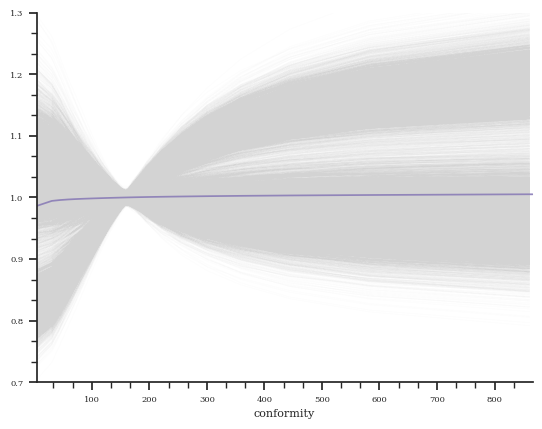

In [133]:
fig,ax=plt.subplots()

ice19 = ice_dataset_19_rescale["conformity__RNN_Model__ice"].values[:,:-1]  # shape (110000, 20)
bins19 = ice_dataset_19_rescale["conformity__bin_values"].values[:-1]
for i in range(ice19.shape[0]):
    c = "lightgrey"
    ax.plot(
        bins19,
        ice19[i],
        # color=colors19[i], # 渐变做法
        color=c,
        alpha=0.05,      # 你可以根据需要调节
        linewidth=0.5
    )

bins_to_keep = ale_dataset_19_rescale['n_bins__conformity'] != ale_dataset_19_rescale['n_bins__conformity'].loc[-1]
ale_dataset_19_keep = ale_dataset_19_rescale.sel(n_bins__conformity=bins_to_keep)

fig,ax = explainer.plot_ale(
    ale=ale_dataset_19_keep,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    # 不再让 plot_ale 自动画 ICE，所以不传 ice_curves
    line_kws={"line_colors": 'm'},  # ALE 颜色保持为洋红 'm'
    hist_color='w',
    # yscale='symlog',
    # y_linscale=1.1,
    show_colorbar=False,
    wspace=0.15,
    ax=ax
)

ax.set_ylim(bottom = 0.7, top = 1.3)
ax_right = get_twinx(ax)
if ax_right:
    ax_right.set_visible(False)

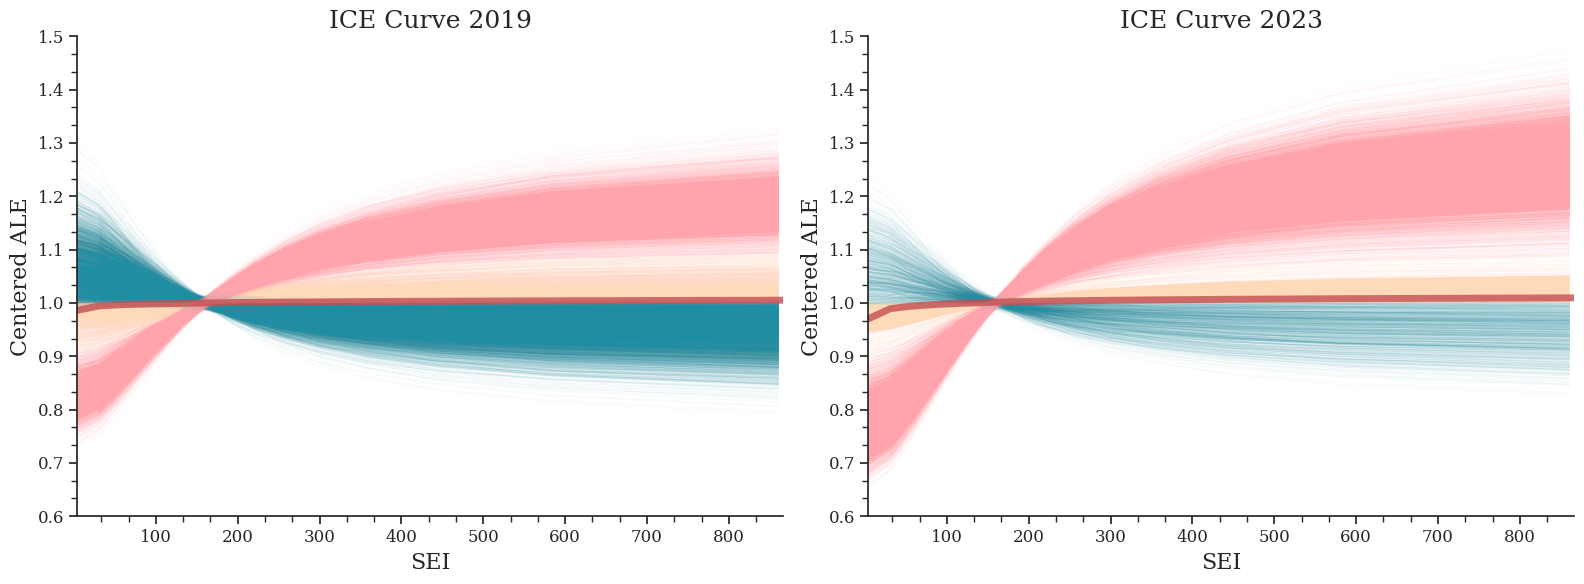

In [145]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# ========= 左图：2019 ==========
ax = axs[0]

# ICE 数据
ice19 = ice_dataset_19_rescale["conformity__RNN_Model__ice"].values[:, :-1]
bins19 = ice_dataset_19_rescale["conformity__bin_values"].values[:-1]

for i in range(ice19.shape[0]):
    c = cluster_colors[labels19[i]]
    ax.plot(
        bins19,
        ice19[i],
        color=c,
        # color=colors19[i],
        alpha=0.05,
        linewidth=0.5
    )

# ALE 去掉重复 bin
mask19 = ale_dataset_19_rescale['n_bins__conformity'] != ale_dataset_19_rescale['n_bins__conformity'].values[-1]
ale19 = ale_dataset_19_rescale.sel(n_bins__conformity=mask19)

# ALE 曲线覆盖
_, ax = explainer.plot_ale(
    ale=ale19,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={"line_colors": 'r', "linewidth": 5},
    hist_color='w',
    show_colorbar=False,
    wspace=0.15,
    ax=ax
)

ax.set_ylim(0.6, 1.5)

ax.set_xlabel('SEI', fontsize=16)
ax.set_ylabel('Centered ALE', fontsize=16)
ax.set_title('ICE Curve 2019', fontsize=18)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax_right = get_twinx(ax)
if ax_right:
    ax_right.set_visible(False)


# ========= 右图：2023 ==========
ax = axs[1]

# ICE
ice23 = ice_dataset_23_rescale["conformity__RNN_Model__ice"].values[:, :-1]
bins23 = ice_dataset_23_rescale["conformity__bin_values"].values[:-1]

for i in range(ice23.shape[0]):
    c = cluster_colors[labels23[i]]
    ax.plot(
        bins23,
        ice23[i],
        color=c,
        # color=colors23[i],
        alpha=0.05,
        linewidth=0.5
    )

# ALE 去掉重复 bin
mask23 = ale_dataset_23_rescale['n_bins__conformity'] != ale_dataset_23_rescale['n_bins__conformity'].values[-1]
ale23 = ale_dataset_23_rescale.sel(n_bins__conformity=mask23)

_, ax = explainer.plot_ale(
    ale=ale23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={"line_colors": 'r', "linewidth": 5},
    hist_color='w',
    show_colorbar=False,
    wspace=0.15,
    ax=ax
)

ax.set_ylim(0.6, 1.5)

ax.set_xlabel('SEI', fontsize=16)
ax.set_ylabel('Centered ALE', fontsize=16)
ax.set_title('ICE Curve 2023', fontsize=18)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax_right = get_twinx(ax)
if ax_right:
    ax_right.set_visible(False)

plt.tight_layout()
plt.show()
